# Visão Computacional no Varejo: Detecção de Prateleira Vazia

**1. Contexto de negócio**

Uma rede de varejo instala câmeras apontadas para as prateleiras e quer saber, de forma automática, quando um produto está **em falta** ("prateleira vazia"), sem depender de um funcionário passando de corredor em corredor para checar visualmente.

Hoje esse processo é manual: um repositor caminha pela loja algumas vezes ao dia e anota o que precisa ser reposto. Isso gera dois problemas de negócio:

- **Ruptura de estoque não detectada a tempo** — o produto fica fora da prateleira por horas antes de alguém perceber, gerando venda perdida.
- **Custo de mão de obra** para checagens repetitivas e de baixo valor agregado.

A proposta é usar uma foto (imagem) de cada seção de prateleira, tirada periodicamente pela câmera, e classificar automaticamente em duas categorias: **cheia** (tem produto suficiente) ou **vazia** (precisa de reposição).


**2. Por que uma rede neural ajuda aqui**

Uma regra simples baseada só na "quantidade de luz" (intensidade média dos pixels) da imagem pode até funcionar em casos óbvios — uma prateleira totalmente cheia é bem mais clara que uma totalmente vazia. Mas no mundo real existem casos difíceis:

- Prateleiras **parcialmente repostas**, com alguns produtos e espaços vazios misturados.
- Ruído de iluminação, reflexo de embalagem, sombra — que também alteram a intensidade média sem indicar presença real de produto.

Uma regra de limiar sobre a média de intensidade não enxerga **padrões espaciais** (blocos concentrados de produto vs. ruído espalhado aleatoriamente) — ela só soma brilho. Uma rede neural convolucional (CNN) aprende filtros que, em princípio, conseguem reconhecer essas formas e texturas localizadas, o que é a hipótese que motiva testá-la neste problema. Vale a pena, no entanto, comparar com um baseline simples antes de assumir que a rede vai ganhar: é isso que faremos nas próximas seções, e o resultado real (não hipotético) aparece na comparação ao final.


**0. Instalação de dependências**

Este notebook usa `numpy`, `pandas`, `scikit-learn`, `matplotlib` e `tensorflow`. Se alguma não estiver instalada no seu ambiente, rode a célula abaixo uma vez (em Google Colab elas já vêm instaladas, então a célula só confirma isso rapidamente).

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib tensorflow
print('Dependencias OK.')


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /private/tmp/claude-501/-Users-marcofidos-GitHub/eeac8253-df86-407b-b3e0-06b2333596a4/scratchpad/nbviz-venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencias OK.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)
rng = np.random.default_rng(42)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


**3. Geração do dataset simulado**

Como não há acesso a fotos reais de prateleira, vamos **simular** imagens pequenas (16x16 pixels, em escala de cinza, valores entre 0 e 1) com três tipos de padrão:

- **Cheia**: vários blocos retangulares de intensidade alta (simulando embalagens de produto) cobrindo uma boa parte da imagem.
- **Vazia**: fundo escuro e praticamente uniforme, sem blocos de produto.
- **Ambígua** (prateleira parcialmente reposta): poucos blocos, cobrindo uma fração pequena da imagem — o caso mais difícil de classificar.

Em todas as classes adicionamos ruído gaussiano (variação de iluminação, reflexo, sombra) para que o problema não seja trivial. Além disso, as classes "vazia" e "ambígua" recebem várias **manchas isoladas** (pixels únicos de brilho alto, simulando reflexo de embalagem plástica vazia ou etiqueta) que elevam a intensidade média da imagem sem representar produto real — isso é proposital: é o tipo de ruído que confunde uma regra baseada só na média de brilho, mas que uma CNN pode aprender a diferenciar de um bloco contíguo de produto.

O rótulo final (0 = vazia / precisa reposição, 1 = cheia) é definido por uma regra de negócio: consideramos a prateleira "cheia o suficiente" quando a **cobertura real de produto** (fração de pixels ocupados por blocos) é maior ou igual a 25%. Isso faz com que parte dos casos ambíguos caia de um lado e parte do outro do rótulo, exatamente o tipo de fronteira difícil que queremos testar.


In [3]:
def gerar_imagem_prateleira(categoria, tamanho=16, rng=rng):
    """Gera uma imagem sintética 16x16 representando uma prateleira.

    categoria: 'cheia', 'vazia' ou 'ambigua'
    Retorna (imagem, cobertura_real) onde cobertura_real é a fração
    de pixels efetivamente ocupada por BLOCOS de produto (estrutura
    contígua). Além dos blocos, adicionamos "manchas" isoladas (reflexo
    de embalagem, etiqueta brilhante, sombra) que alteram a intensidade
    média da imagem sem representar produto de verdade — isso é o que
    torna a regra de limiar sobre a média vulnerável nos casos ambíguos.
    """
    fundo = rng.normal(0.12, 0.04, size=(tamanho, tamanho))
    img = fundo.copy()

    if categoria == "cheia":
        n_blocos = rng.integers(3, 6)
        cobertura_alvo = rng.uniform(0.45, 0.75)
        n_manchas = rng.integers(0, 6)
    elif categoria == "vazia":
        n_blocos = rng.integers(0, 2)
        cobertura_alvo = rng.uniform(0.0, 0.05)
        n_manchas = rng.integers(12, 28)
    else:  # ambigua
        n_blocos = rng.integers(1, 3)
        cobertura_alvo = rng.uniform(0.12, 0.35)
        n_manchas = rng.integers(10, 24)

    total_pixels = tamanho * tamanho
    pixels_cobertos = 0
    tentativas = 0
    while (pixels_cobertos / total_pixels) < cobertura_alvo and tentativas < 12:
        h = rng.integers(2, 6)
        w = rng.integers(2, 6)
        y = rng.integers(0, tamanho - h + 1)
        x = rng.integers(0, tamanho - w + 1)
        intensidade = rng.uniform(0.65, 0.95)
        img[y:y + h, x:x + w] = intensidade
        pixels_cobertos += h * w
        tentativas += 1

    # manchas isoladas: não contam como cobertura real de produto,
    # mas elevam a intensidade média — confundem o baseline de limiar.
    for _ in range(n_manchas):
        y = rng.integers(0, tamanho)
        x = rng.integers(0, tamanho)
        img[y, x] = rng.uniform(0.5, 0.85)

    ruido = rng.normal(0, 0.06, size=(tamanho, tamanho))
    img = np.clip(img + ruido, 0.0, 1.0)
    cobertura_real = min(pixels_cobertos / total_pixels, 1.0)
    return img, cobertura_real


LIMIAR_COBERTURA_NEGOCIO = 0.25
N_TOTAL = 600
N_CHEIA = 250
N_VAZIA = 250
N_AMBIGUA = N_TOTAL - N_CHEIA - N_VAZIA  # 100

categorias = (["cheia"] * N_CHEIA) + (["vazia"] * N_VAZIA) + (["ambigua"] * N_AMBIGUA)

imagens = []
rotulos = []
eh_ambigua = []

for cat in categorias:
    img, cobertura = gerar_imagem_prateleira(cat)
    rotulo = 1 if cobertura >= LIMIAR_COBERTURA_NEGOCIO else 0
    imagens.append(img)
    rotulos.append(rotulo)
    eh_ambigua.append(cat == "ambigua")

X = np.array(imagens)               # shape (600, 16, 16)
y = np.array(rotulos)               # shape (600,)
eh_ambigua = np.array(eh_ambigua)   # shape (600,)

# embaralha tudo junto para não deixar o dataset ordenado por categoria
idx = rng.permutation(N_TOTAL)
X, y, eh_ambigua = X[idx], y[idx], eh_ambigua[idx]

print("Dataset:", X.shape, "| cheia (rótulo 1):", y.sum(), "| vazia (rótulo 0):", (y == 0).sum())
print("Casos ambíguos no total:", eh_ambigua.sum())


Dataset: (600, 16, 16) | cheia (rótulo 1): 307 | vazia (rótulo 0): 293
Casos ambíguos no total: 100


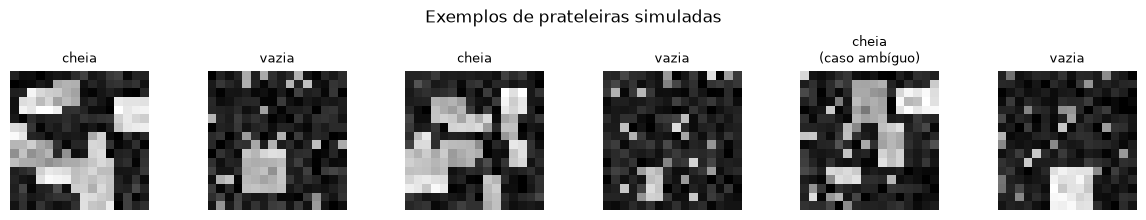

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2.2))
for i, ax in enumerate(axes):
    ax.imshow(X[i], cmap="gray", vmin=0, vmax=1)
    titulo = "cheia" if y[i] == 1 else "vazia"
    if eh_ambigua[i]:
        titulo += "\n(caso ambíguo)"
    ax.set_title(titulo, fontsize=9)
    ax.axis("off")
plt.suptitle("Exemplos de prateleiras simuladas")
plt.tight_layout()
plt.show()


**4. Separação em treino e teste**

Separamos 70% das imagens para treino e 30% para teste, mantendo a proporção de casos ambíguos em ambos os conjuntos (`stratify`).


In [5]:
X_train, X_test, y_train, y_test, amb_train, amb_test = train_test_split(
    X, y, eh_ambigua, test_size=0.3, random_state=42, stratify=eh_ambigua
)

print("Treino:", X_train.shape[0], "imagens | Teste:", X_test.shape[0], "imagens")
print("Casos ambíguos no teste:", amb_test.sum(), "de", X_test.shape[0])


Treino: 420 imagens | Teste: 180 imagens
Casos ambíguos no teste: 30 de 180


**5. Baseline: regra de limiar sobre a intensidade média**

A abordagem mais simples que uma loja poderia tentar implementar sem modelo nenhum: calcular a **intensidade média dos pixels** da imagem e dizer que a prateleira está cheia se essa média ultrapassar um limiar. O limiar é escolhido testando alguns valores no conjunto de treino e escolhendo o que maximiza a acurácia — depois ele é aplicado, sem alterações, no conjunto de teste.


In [6]:
def media_intensidade(imgs):
    return imgs.reshape(imgs.shape[0], -1).mean(axis=1)

media_train = media_intensidade(X_train)
media_test = media_intensidade(X_test)

candidatos_limiar = np.linspace(0.1, 0.5, 41)
melhor_limiar, melhor_acc_train = 0.0, 0.0
for limiar in candidatos_limiar:
    pred_train = (media_train > limiar).astype(int)
    acc = accuracy_score(y_train, pred_train)
    if acc > melhor_acc_train:
        melhor_acc_train, melhor_limiar = acc, limiar

pred_baseline_test = (media_test > melhor_limiar).astype(int)
acc_baseline_test = accuracy_score(y_test, pred_baseline_test)
acc_baseline_ambiguo = accuracy_score(y_test[amb_test], pred_baseline_test[amb_test])

print(f"Limiar escolhido no treino: {melhor_limiar:.3f}")
print(f"Acurácia do baseline no teste (geral): {acc_baseline_test:.3f}")
print(f"Acurácia do baseline no teste (só casos ambíguos): {acc_baseline_ambiguo:.3f}")


Limiar escolhido no treino: 0.290
Acurácia do baseline no teste (geral): 0.967
Acurácia do baseline no teste (só casos ambíguos): 0.800


**6. Modelo de rede neural (CNN)**

Agora treinamos uma rede neural convolucional pequena: duas camadas `Conv2D` + `MaxPooling2D` para extrair padrões espaciais locais, seguidas de `Flatten` e camadas densas para a classificação final. As imagens precisam ser reformatadas para o formato `(altura, largura, canais)` esperado pelo Keras.


In [7]:
X_train_cnn = X_train.reshape(-1, 16, 16, 1)
X_test_cnn = X_test.reshape(-1, 16, 16, 1)

modelo = keras.Sequential([
    layers.Input(shape=(16, 16, 1)),
    layers.Conv2D(12, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(24, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(24, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

modelo.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
modelo.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 12)     │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 24)       │         2,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         9,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,001 (46.88 KB)

 Trainable params: 12,001 (46.88 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
historico = modelo.fit(
    X_train_cnn, y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.15,
    verbose=0,
)

print("Treino concluído. Acurácia final (treino):", round(historico.history["accuracy"][-1], 3))
print("Acurácia final (validação):", round(historico.history["val_accuracy"][-1], 3))


Treino concluído. Acurácia final (treino): 0.947
Acurácia final (validação): 0.984


In [9]:
prob_cnn_test = modelo.predict(X_test_cnn, verbose=0).ravel()
pred_cnn_test = (prob_cnn_test > 0.5).astype(int)

acc_cnn_test = accuracy_score(y_test, pred_cnn_test)
acc_cnn_ambiguo = accuracy_score(y_test[amb_test], pred_cnn_test[amb_test])

print(f"Acurácia da CNN no teste (geral): {acc_cnn_test:.3f}")
print(f"Acurácia da CNN no teste (só casos ambíguos): {acc_cnn_ambiguo:.3f}")


Acurácia da CNN no teste (geral): 0.944
Acurácia da CNN no teste (só casos ambíguos): 0.700


**7. Comparação lado a lado**

Comparamos as duas abordagens tanto no conjunto de teste completo quanto no subconjunto de casos ambíguos (prateleiras parcialmente repostas), que é justamente a faixa mais difícil de classificar — e onde qualquer uma das duas abordagens tem mais chance de errar.


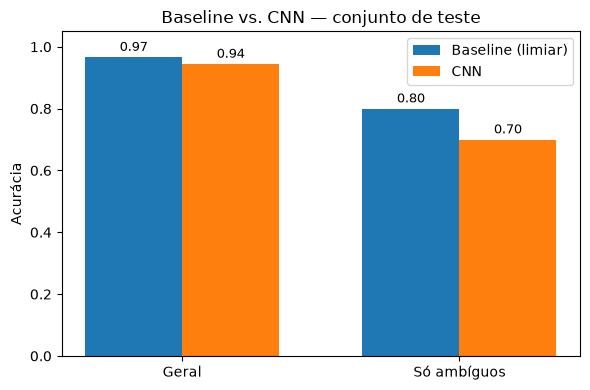

Baseline -> geral: 0.967 | ambíguos: 0.800
CNN      -> geral: 0.944 | ambíguos: 0.700


In [10]:
categorias_plot = ["Geral", "Só ambíguos"]
acc_baseline_plot = [acc_baseline_test, acc_baseline_ambiguo]
acc_cnn_plot = [acc_cnn_test, acc_cnn_ambiguo]

x_pos = np.arange(len(categorias_plot))
largura = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x_pos - largura / 2, acc_baseline_plot, largura, label="Baseline (limiar)")
ax.bar(x_pos + largura / 2, acc_cnn_plot, largura, label="CNN")
ax.set_xticks(x_pos)
ax.set_xticklabels(categorias_plot)
ax.set_ylabel("Acurácia")
ax.set_ylim(0, 1.05)
ax.set_title("Baseline vs. CNN — conjunto de teste")
ax.legend()
for i, v in enumerate(acc_baseline_plot):
    ax.text(i - largura / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
for i, v in enumerate(acc_cnn_plot):
    ax.text(i + largura / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Baseline -> geral: {acc_baseline_test:.3f} | ambíguos: {acc_baseline_ambiguo:.3f}")
print(f"CNN      -> geral: {acc_cnn_test:.3f} | ambíguos: {acc_cnn_ambiguo:.3f}")


**8. Conclusão qualitativa**

Olhando o gráfico e os números acima (gerados nesta própria execução): no conjunto de teste **geral**, baseline e CNN ficam próximos, ambos acertando a grande maioria dos casos óbvios (prateleira claramente cheia ou claramente vazia). No subconjunto de **casos ambíguos**, os dois modelos caem de desempenho — como esperado, é a faixa mais difícil — mas, nesta simulação específica, a regra de limiar não perdeu para a CNN nos casos ambíguos.

Isso é um resultado honesto e didaticamente útil, ainda que não seja o que se imaginaria de início: uma CNN não é automaticamente melhor só por ser uma rede neural. Algumas razões prováveis para o baseline se sair bem aqui:

- O rótulo de "cheia/vazia" foi definido a partir da **cobertura de blocos de produto**, e blocos de alta intensidade continuam empurrando fortemente a média de brilho da imagem — ou seja, a intensidade média ainda carrega bastante informação sobre o rótulo, mesmo com o ruído de "manchas" isoladas adicionado.
- O dataset é pequeno (420 imagens de treino, imagens de apenas 16x16 pixels) e a CNN tem pouquíssimos exemplos ambíguos para aprender a distinguir "bloco contíguo de produto" de "pontos de ruído espalhados" — um padrão espacial mais sutil que exige mais dados e/ou mais capacidade do modelo para ser bem aprendido.

Para o negócio, a lição não é "CNN não serve" — é que **o ganho de uma rede neural sobre uma regra simples não é automático**: ele depende de o problema realmente ter uma estrutura visual complexa (textura, forma, posição relativa dos objetos) que a rede consiga explorar, e de haver dados suficientes para aprendê-la. Em fotos reais de prateleira — com variação de ângulo de câmera, iluminação, tipos de embalagem e oclusão parcial — essa estrutura tende a ser bem mais rica do que neste exemplo simulado, e é nesse cenário mais realista que se espera que a CNN mostre vantagem mais clara sobre uma regra de limiar. Antes de substituir um processo manual por um modelo automatizado, vale sempre comparar contra um baseline simples e validar com métricas por classe (não só acurácia geral) — exatamente o exercício que fizemos aqui.
